In [39]:
%matplotlib inline
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import io
import re
import math
import msoffcrypto
import re
import openpyxl

In [40]:
import geopandas as gpd
from shapely.geometry import Point
from shapely.geometry import box
import time
from geopy.geocoders import Nominatim
from tqdm import tqdm

In [41]:
pd.set_option("display.max_columns", None)

In [42]:
# get coordinates of OHCA cases from xlsx file
filename = "3_OHCA_with_coords.xlsx"
filepath = "../../datasets/" + filename
postal_code_df = pd.read_excel(filepath, sheet_name = 0)
# drop unneeded columns 
postal_code_df.drop(["Location Unknown", "Location Type",
                     "Location Type Other", "Unnamed: 0"],
                     axis = "columns", inplace = True)
print(postal_code_df.head())

   Unnamed: 0.1     Case #  Site # Date of Incident  Location of incident  \
0             0  SGSIN0213       2       2010-04-01              470146.0   
1             1  SGSIN0218       2       2010-04-01              520926.0   
2             2  SGSIN6480       6       2010-04-01              560565.0   
3             3  SGSIN5332       5       2010-04-02              680626.0   
4             4  SGSIN0214       2       2010-04-03              468963.0   

        lat         lon  
0  1.334604  103.911889  
1  1.346122  103.940989  
2  1.369882  103.858475  
3  1.398315  103.745837  
4  1.315317  103.961890  


In [43]:
# turn the longitude and latitude into coordinates
postal_code_df["Coordinates"] = gpd.points_from_xy(postal_code_df["lon"], postal_code_df["lat"])
# turn the coordinates tuple into a shapely point object
locations_gdf = gpd.GeoDataFrame(
    postal_code_df.dropna(subset = ["lat", "lon"]),
    geometry = "Coordinates",
    crs = "EPSG:4326",
)
print(locations_gdf.head())
print('gdf is of type:', type(locations_gdf), "\ncrs is:", locations_gdf.crs)
print('\nThe geometry column is:', locations_gdf.geometry.name)


print("Raw CRS :", locations_gdf.crs)              # what the file *claims*
print("Raw bounds :", locations_gdf.total_bounds)

   Unnamed: 0.1     Case #  Site # Date of Incident  Location of incident  \
0             0  SGSIN0213       2       2010-04-01              470146.0   
1             1  SGSIN0218       2       2010-04-01              520926.0   
2             2  SGSIN6480       6       2010-04-01              560565.0   
3             3  SGSIN5332       5       2010-04-02              680626.0   
4             4  SGSIN0214       2       2010-04-03              468963.0   

        lat         lon                Coordinates  
0  1.334604  103.911889   POINT (103.91189 1.3346)  
1  1.346122  103.940989  POINT (103.94099 1.34612)  
2  1.369882  103.858475  POINT (103.85848 1.36988)  
3  1.398315  103.745837  POINT (103.74584 1.39832)  
4  1.315317  103.961890  POINT (103.96189 1.31532)  
gdf is of type: <class 'geopandas.geodataframe.GeoDataFrame'> 
crs is: EPSG:4326

The geometry column is: Coordinates
Raw CRS : EPSG:4326
Raw bounds : [103.614228   1.224884 104.040501   1.467823]


In [44]:
sg_map = "../../dr_sean_code/MasterPlan2019SubzoneBoundaryNoSeaGEOJSON.geojson"

sg_gdf = gpd.read_file(sg_map)

print(sg_gdf.crs)

EPSG:4326


subzone_n is for subzone's name

subzone_c is for subzone's code

In [45]:
# Extract planning area and subzone from each Description

subzones_n = []
subzones_c = []
planning_areas = []

# Loop through each row of the GeoDataFrame
for description in sg_gdf['Description']:
    subzone_match = re.search(r"<th>SUBZONE_N</th>\s*<td>(.*?)</td>", description)
    subzone_c_match = re.search(r"<th>SUBZONE_C</th>\s*<td>(.*?)</td>", description)
    planning_area_match = re.search(r"<th>PLN_AREA_N</th>\s*<td>(.*?)</td>", description)

    subzones_n.append(subzone_match.group(1) if subzone_match else None)
    subzones_c.append(subzone_c_match.group(1) if subzone_c_match else None)
    planning_areas.append(planning_area_match.group(1) if planning_area_match else None)

# Add new columns to the GeoDataFrame
sg_gdf['SUBZONE_N'] = subzones_n
sg_gdf['SUBZONE_C'] = subzones_c
sg_gdf['PLN_AREA_N'] = planning_areas


print(sg_gdf.crs)
# sg_gdf[["SUBZONE_N", "SUBZONE_C"]].count()

EPSG:4326


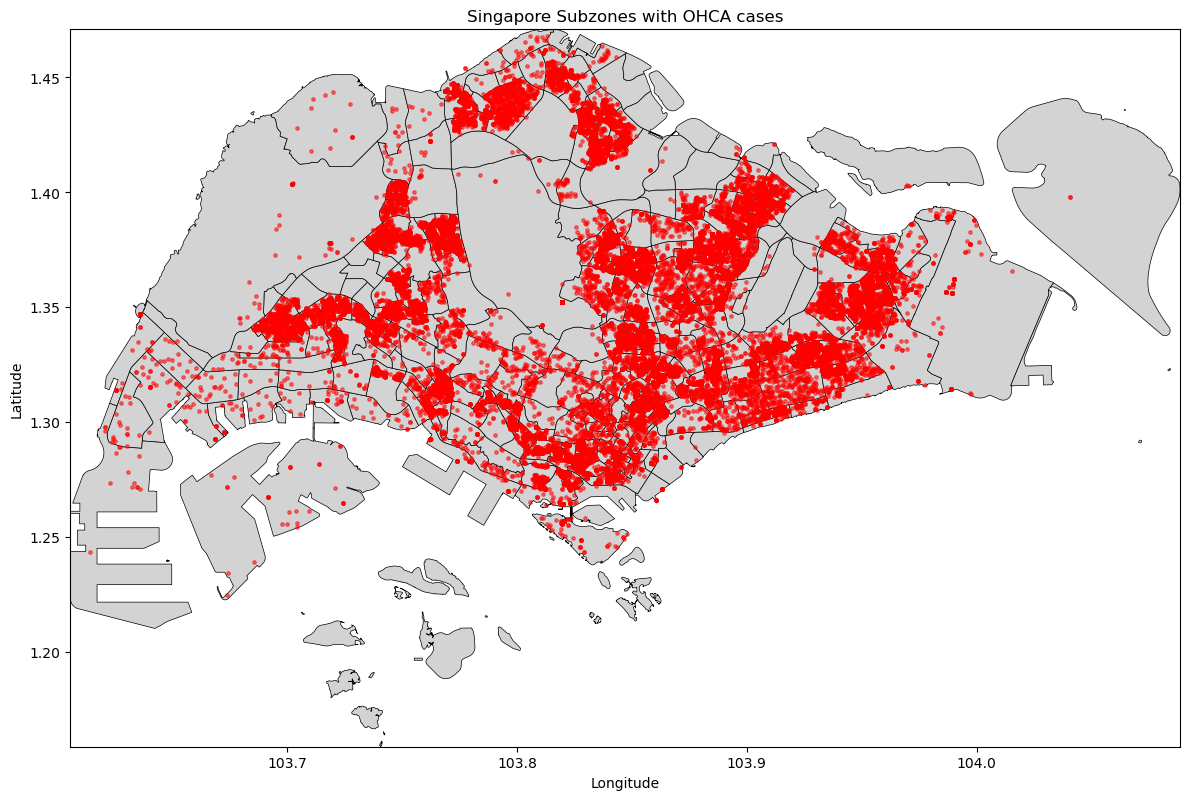

In [46]:
fig, ax = plt.subplots(figsize=(12, 10))
sg_gdf.plot(ax=ax, edgecolor="black", facecolor="lightgray", linewidth=0.5)
locations_gdf.plot(ax=ax, color="red", alpha=0.5, markersize=6)

# lock limits to the map's bounds, ignoring outliers
minx, miny, maxx, maxy = sg_gdf.total_bounds
ax.set_xlim(minx, maxx)
ax.set_ylim(miny, maxy)
# keep the map from looking squashed
ax.set_aspect("equal")

ax.set_title("Singapore Subzones with OHCA cases")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.tight_layout()
plt.show()

Choropleth to visualise the above map

In [47]:
### attach sub-zone attributes to every incident Point
joined = gpd.sjoin(locations_gdf, # left: points
                   sg_gdf,        # right: polygons
                   how = "left",
                   predicate = "within")

# count incidents per sub-zone code or name
counts = (joined.groupby("SUBZONE_C")
          .size()
          .reset_index(name = "cases"))

# merge counts back into the polygon layer
sg_gdf = sg_gdf.merge(counts, on="SUBZONE_C", how="left")
sg_gdf["cases"] = sg_gdf["cases"].fillna(0).astype(int)

<Figure size 1200x1000 with 0 Axes>

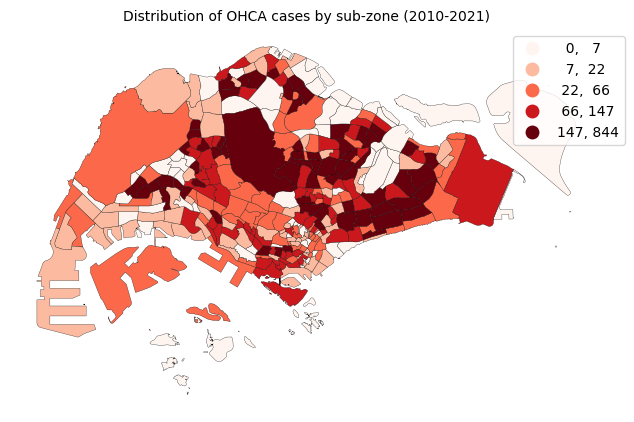

In [48]:
## draw the choropleth
plt.figure(figsize = (12, 10))

ax = sg_gdf.plot(column="cases",
                       cmap="Reds",
                       scheme="quantiles",
                       k=5,
                       linewidth=0.2,
                       edgecolor="black",
                       legend=True,
                       legend_kwds={"fmt": "{:.0f}",
                                    "bbox_to_anchor": (1.05, 1),
                                    "loc": "upper right"})

# Add sub-zone name labels
# for idx, row in sg_gdf.iterrows():
#     centroid = row['geometry'].centroid
#     ax.text(centroid.x, centroid.y, row['SUBZONE_C'], 
#             fontsize=6, ha='center', va='center', color='black')

ax.set_axis_off()
ax.set_title("Distribution of OHCA cases by sub-zone (2010-2021)", fontsize=10)
plt.tight_layout()
plt.show()

Use the Joined dataframe to group incidents by subzones and month

In [49]:
joined["Date of Incident"] = pd.to_datetime(joined["Date of Incident"])
# print(joined["Date of Incident"])

# extract year-month
joined["year_month"] = joined["Date of Incident"].dt.to_period("M")

monthly_counts = joined.groupby(["SUBZONE_C", "year_month"]).size().reset_index(name = "cases")

monthly_counts["year_month"] = monthly_counts["year_month"].dt.to_timestamp()
print(monthly_counts)
monthly_counts.to_excel("../../datasets/monthly_cases_by_subzone.xlsx")

      SUBZONE_C year_month  cases
0        AMSZ01 2010-05-01      1
1        AMSZ01 2010-07-01      2
2        AMSZ01 2010-09-01      1
3        AMSZ01 2011-05-01      1
4        AMSZ01 2011-09-01      1
...         ...        ...    ...
15126    YSSZ09 2021-08-01      1
15127    YSSZ09 2021-09-01      2
15128    YSSZ09 2021-10-01      5
15129    YSSZ09 2021-11-01      7
15130    YSSZ09 2021-12-01      8

[15131 rows x 3 columns]


In [50]:
from prophet import Prophet

Importing plotly failed. Interactive plots will not work.


Testing the plot for one subzone first

16:27:05 - cmdstanpy - INFO - Chain [1] start processing
16:27:05 - cmdstanpy - INFO - Chain [1] done processing


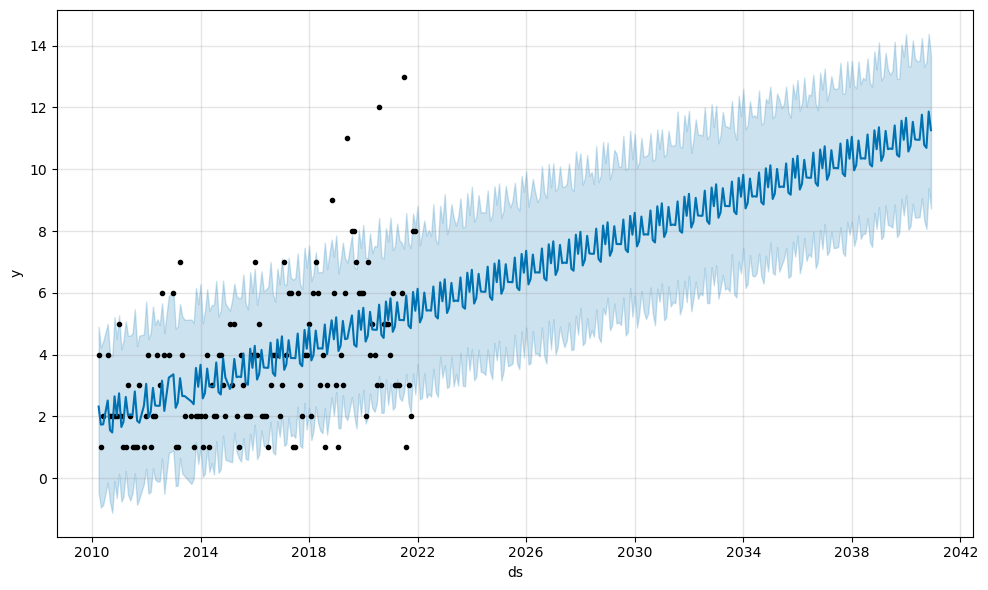

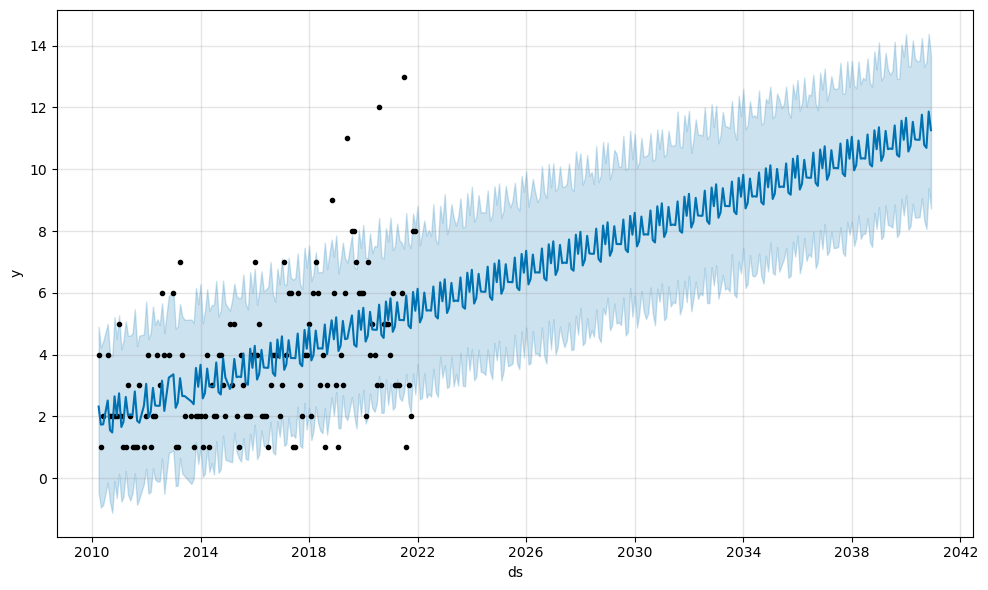

In [51]:
subzones = monthly_counts["SUBZONE_C"].unique().tolist()
# print(len(subzones))

forecast_df = monthly_counts[monthly_counts['SUBZONE_C'] == 'TMSZ03'][['year_month', 'cases']]
forecast_df.columns = ['ds', 'y']  # Prophet requires these names

model = Prophet(yearly_seasonality=True)
model.fit(forecast_df)

future = model.make_future_dataframe(periods=(2040 - 2021) * 12, freq='MS')  # forecast till 2040
forecast = model.predict(future)

# Plot
model.plot(forecast)
# print(forecast_df.head(10))
# print(forecast_df.shape)
# print(forecast_df['y'].isna().sum())

Doing forecasting with prophet for all subzones and saving into a csv

In [55]:
all_forecasts = []

# Loop through subzone codes
for subzone in tqdm(subzones):

    # Filter and prepare data
    df_zone = monthly_counts[monthly_counts['SUBZONE_C'] == subzone][['year_month', 'cases']].copy()
    df_zone.columns = ['ds', 'y']
    
    # Skip zones with < 2 data points (Prophet needs at least 2)
    if df_zone['y'].notna().sum() < 2:
        continue

    # Initialize and fit model
    model = Prophet(yearly_seasonality=True)
    model.fit(df_zone)

    # Forecast to 2040 (monthly)
    future = model.make_future_dataframe(periods=(2040 - 2021) * 12, freq='MS')
    forecast = model.predict(future)

    # Add subzone code to result
    forecast['SUBZONE_C'] = subzone

    # Optional: Add original name too (if you have lookup)
    # forecast['SUBZONE_N'] = name_lookup[subzone]

    # Append to results
    all_forecasts.append(forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper', 'SUBZONE_C']])

  0%|          | 0/307 [00:00<?, ?it/s]16:41:42 - cmdstanpy - INFO - Chain [1] start processing
16:41:42 - cmdstanpy - INFO - Chain [1] done processing
  0%|          | 1/307 [00:00<01:26,  3.53it/s]16:41:42 - cmdstanpy - INFO - Chain [1] start processing
16:41:42 - cmdstanpy - INFO - Chain [1] done processing
  1%|          | 2/307 [00:00<01:00,  5.03it/s]16:41:42 - cmdstanpy - INFO - Chain [1] start processing
16:41:42 - cmdstanpy - INFO - Chain [1] done processing
  1%|          | 3/307 [00:00<00:52,  5.79it/s]16:41:42 - cmdstanpy - INFO - Chain [1] start processing
16:41:43 - cmdstanpy - INFO - Chain [1] done processing
  1%|▏         | 4/307 [00:00<00:59,  5.08it/s]16:41:43 - cmdstanpy - INFO - Chain [1] start processing
16:41:43 - cmdstanpy - INFO - Chain [1] done processing
  2%|▏         | 5/307 [00:01<01:21,  3.69it/s]16:41:43 - cmdstanpy - INFO - Chain [1] start processing
16:41:43 - cmdstanpy - INFO - Chain [1] done processing
  2%|▏         | 6/307 [00:01<01:26,  3.49it/s]1

KeyboardInterrupt: 

Save forecasts to CSV

In [11]:
all_forecast_df = pd.concat(all_forecasts, ignore_index = True)

all_forecast_df.to_csv("../../datasets/subzones_forecasts.csv")

NameError: name 'all_forecasts' is not defined

Read subzones forecast from CSV

In [12]:
all_forecast_df = pd.read_csv("../../datasets/subzones_forecasts.csv")
print(all_forecast_df.head())
print(all_forecast_df['SUBZONE_C'].nunique())

   Unnamed: 0          ds      yhat  yhat_lower  yhat_upper SUBZONE_C
0           0  2010-05-01  1.321979    0.777577    1.847435    AMSZ01
1           1  2010-07-01  1.473145    0.955234    1.983451    AMSZ01
2           2  2010-09-01  0.897634    0.399426    1.461228    AMSZ01
3           3  2011-05-01  0.803743    0.228334    1.341343    AMSZ01
4           4  2011-09-01  0.905895    0.336336    1.439606    AMSZ01
301


Save plots into a graph for better visualisation

100%|██████████| 51/51 [00:42<00:00,  1.19it/s]

Plots saved


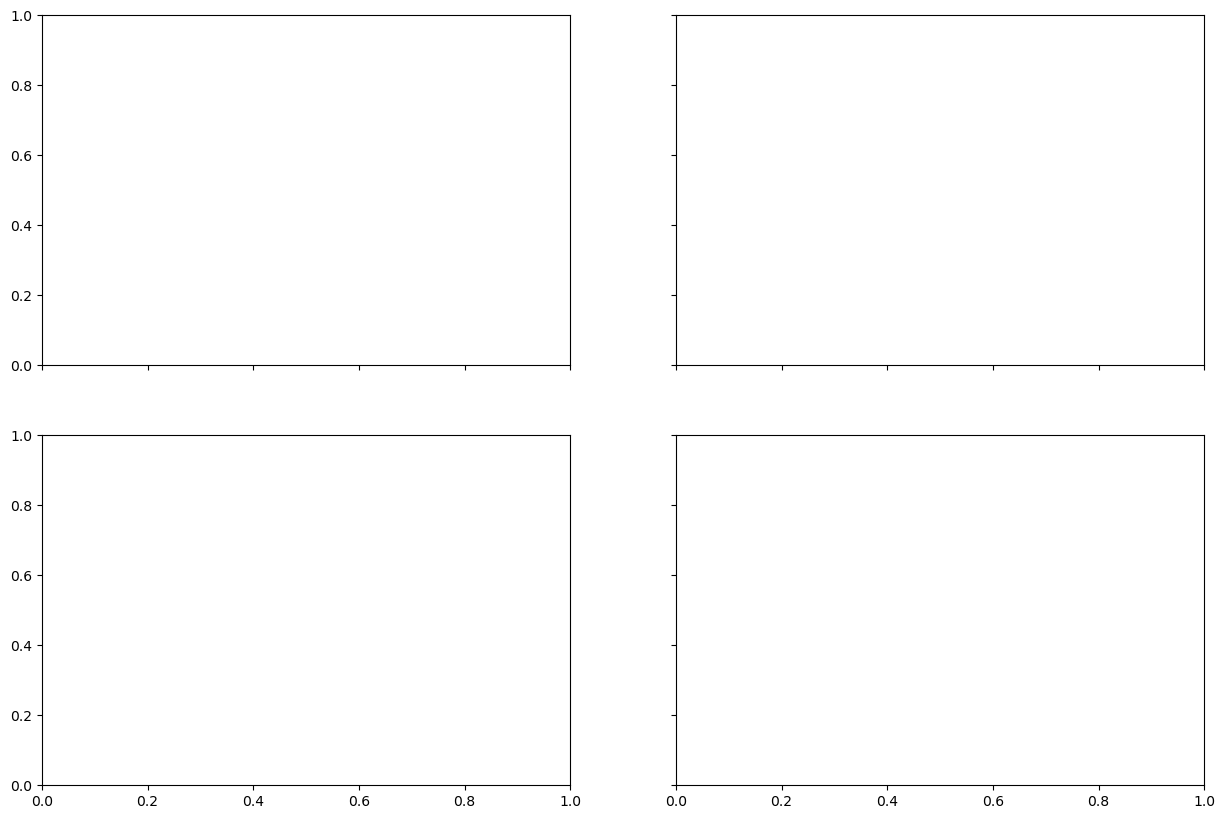

In [54]:
from matplotlib.backends.backend_pdf import PdfPages

plots_per_page = 6
n_cols = 3
n_rows = 2

subzones_to_plot = all_forecast_df["SUBZONE_C"].unique().tolist()

# map subzone's code to their names
code_to_name = sg_gdf[['SUBZONE_C', 'SUBZONE_N']].drop_duplicates().set_index('SUBZONE_C')['SUBZONE_N'].to_dict()

fig, axes = plt.subplots(2, 2, figsize=(15, 10), sharex=True, sharey=True)

# Create PDF writer
with PdfPages("OHCA_forecasts_by_subzone.pdf") as pdf:

    for i in tqdm(range(0, len(subzones_to_plot), plots_per_page)):
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 10), sharex=True, sharey=True)
        axes = axes.flatten()
        
        for ax, subzone in zip(axes, subzones_to_plot[i:i+plots_per_page]):
            forecast_zone = all_forecast_df[all_forecast_df['SUBZONE_C'] == subzone].copy()

            # Ensure correct dtypes
            forecast_zone['yhat'] = pd.to_numeric(forecast_zone['yhat'], errors='coerce')
            forecast_zone['yhat_lower'] = pd.to_numeric(forecast_zone['yhat_lower'], errors='coerce')
            forecast_zone['yhat_upper'] = pd.to_numeric(forecast_zone['yhat_upper'], errors='coerce')
            forecast_zone['ds'] = pd.to_datetime(forecast_zone['ds'], errors='coerce')
            
            # drop invalid roles
            # forecast_zone = forecast_zone.dropna(subset=['ds', 'yhat', 'yhat_lower', 'yhat_upper'])
            
            subzone_name = code_to_name.get(subzone, subzone) # fallback to code if name not found
            if forecast_zone.empty:
                ax.set_title(f"Subzone {subzone_name} (no data)")
                ax.axis('off')
                continue

            ax.plot(forecast_zone['ds'], forecast_zone['yhat'], label='Forecast', color='blue')
            ax.fill_between(forecast_zone['ds'],
                            forecast_zone['yhat_lower'],
                            forecast_zone['yhat_upper'],
                            color='lightblue', alpha=0.5)
            
            ax.set_title(f"Subzone {subzone_name}")
            ax.grid(True)
        
        # Hide unused subplots on the last page
        for j in range(len(subzones_to_plot[i:i+plots_per_page]), plots_per_page):
            fig.delaxes(axes[j])
        
        fig.suptitle(f"OHCA Forecasts by Subzone (Monthly till 2040) - Page {i//plots_per_page + 1}", fontsize=18)
        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        
        # Save current figure to PDF
        pdf.savefig(fig)
        plt.close(fig)  # free memory
print("Plots saved")

Display yearly forecast from 2022 to 2040

In [29]:
## group monthly forecast to yearly totals
# Ensure 'ds' is datetime
all_forecast_df['ds'] = pd.to_datetime(all_forecast_df['ds'], errors='coerce')

# Extract year
all_forecast_df['year'] = all_forecast_df['ds'].dt.year

# Group by year and subzone, sum forecasted OHCA cases
forecast_yearly = (
    all_forecast_df
    .query('year >= 2022')
    .groupby(['SUBZONE_C', 'year'])['yhat']
    .sum()
    .reset_index()
)


Save plots to file

In [36]:
# Initialize PDF writer
with PdfPages("OHCA_forecasts_by_subzone_2022_2040.pdf") as pdf:
    for year in tqdm(range(2022, 2041)):
        sg_gdf_year = sg_gdf.copy()

        # Merge forecast for the current year
        forecast_for_year = forecast_yearly.query('year == @year')

        # Check forecast data presence
        if forecast_for_year.empty:
            print(f"No forecast data for year {year}, skipping.")
            continue

        sg_gdf_year = sg_gdf_year.merge(
            forecast_for_year,
            on='SUBZONE_C',
            how='left'
        )

        sg_gdf_year['yhat'] = sg_gdf_year['yhat'].fillna(0)

        # Plot
        fig, ax = plt.subplots(figsize=(12, 10))

        sg_gdf_year.plot(column='yhat',
                         cmap='Reds',
                         scheme='quantiles',
                         k=5,
                         linewidth=0.2,
                         edgecolor='black',
                         legend=True,
                         legend_kwds={
                             "fmt": "{:.0f}",
                             "bbox_to_anchor": (1.05, 1),
                             "loc": "upper right"
                         },
                         ax=ax)

        ax.set_axis_off()
        ax.set_title(f"Forecasted OHCA Cases by Subzone (Year: {year})", fontsize=14)
        plt.tight_layout()

        # Save this plot as a page in the PDF
        pdf.savefig(fig)
        plt.close(fig)

print("Done!")

100%|██████████| 19/19 [00:04<00:00,  3.97it/s]

Done!
